In [29]:
%load_ext autoreload
%autoreload 2

'''
Importing the modules
'''
import config_2D_coupling_V4 as cfg         # config = physical & simulation parameters 
from solver_2D_coupling_V4 import *         # solver = FEM method + pmls
import post_process_2D_coupling_V4 as my_pp # post_process = plotting functions
from ngsolve import exp 
import numpy as np  


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
from ngsolve import exp, IfPos, sqrt
import numpy as np

def create_density_profile(x_sym, z_sym):
    '''
    Define a 2D (x,z) arbitrary profile of density n_e(x,z).
    Upgraded with a Smoothed Heaviside blending to keep strictly linear segments
    while ensuring C1 continuity locally at the junctions to prevent FEM reflections.
    '''
    # TYPE: str
    prof_type = cfg.PLASMA.get('profile_type', 'exponential')

    if prof_type == 'constant_density':
        # TYPE: float
        return cfg.PLASMA['ne_constant']

    elif prof_type == 'exponential_density':
        # TYPE: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        n_edge = cfg.PLASMA['lin_prof_n'][0]
        n_core = cfg.PLASMA['lin_prof_n'][-1]

        # TYPE: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_edge * exp(lambda_val * x_sym)
        return n_e_profile

    elif prof_type == 'piecewise_linear_density':
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # Smoothing parameter (e.g., 0.002 meters = 2 mm transition zone)
        # TYPE: float
        smooth_width = 0.002 

        # Initialize the profile with the very first linear segment
        # TYPE: float
        slope_0 = (n_pts[1] - n_pts[0]) / (x_pts[1] - x_pts[0])
        
        # TYPE: ngsolve.CoefficientFunction
        n_e_profile = n_pts[0] + slope_0 * (x_sym - x_pts[0])

        # Sequentially blend the next segments using a Smoothed Heaviside step
        for i in range(1, len(x_pts) - 1):
            # TYPE: float
            x_c = x_pts[i]
            n_c = n_pts[i]
            
            # TYPE: float
            slope_prev = (n_pts[i] - n_pts[i-1]) / (x_pts[i] - x_pts[i-1])
            slope_next = (n_pts[i+1] - n_pts[i]) / (x_pts[i+1] - x_pts[i])

            # Line equations for previous and next segments
            # TYPE: ngsolve.CoefficientFunction
            L_prev = n_c + slope_prev * (x_sym - x_c)
            L_next = n_c + slope_next * (x_sym - x_c)

            # Smoothed Heaviside transition centered at x_c
            # TYPE: ngsolve.CoefficientFunction
            dx = x_sym - x_c
            H_smooth = 0.5 * (1.0 + dx / sqrt(dx**2 + smooth_width**2))

            # Add the difference modulated by the smooth transition
            n_e_profile = n_e_profile + (L_next - L_prev) * H_smooth

        return n_e_profile

    elif prof_type == 'piecewise_linear_brute':
        # Pure C0 piecewise linear with sharp corners (for benchmarking reflections)
        # TYPE: np.ndarray, SHAPE: (N,)
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])

        # TYPE: float | ngsolve.CoefficientFunction
        n_e_profile = 0.0

        for i in range(len(x_pts) - 1):
            # TYPE: float
            x0, x1 = x_pts[i], x_pts[i+1]
            n0, n1 = n_pts[i], n_pts[i+1]

            # TYPE: float
            slope = (n1 - n0) / (x1 - x0)
            
            # TYPE: ngsolve.CoefficientFunction
            line = n0 + slope * (x_sym - x0)

            # TYPE: ngsolve.CoefficientFunction
            if i == len(x_pts) - 2:
                mask = IfPos(x_sym - x0, 1.0, 0.0)
            else:
                mask = IfPos(x_sym - x0, 1.0, 0.0) - IfPos(x_sym - x1, 1.0, 0.0)

            n_e_profile = n_e_profile + mask * line

        return n_e_profile

    else:
        raise ValueError("Profile type not supported. Use 'exponential_density', 'piecewise_linear_density', or 'piecewise_linear_brute'.")

In [31]:
def create_density_profile(x_val,z_val):
    """
    Unified density profile calculator using Numpy. 
    Matches the mathematical logic used in the FEM solver.
    """
    # TYPE prof_type: str
    prof_type = cfg.PLASMA.get('profile_type', 'constant_density')
    
    if prof_type == 'constant_density':
        # TYPE ne_constant: float
        ne_constant = cfg.PLASMA['ne_constant']
        # TYPE: np.ndarray
        return np.full_like(x_val, ne_constant)

    elif prof_type == 'exponential_density':
        # TYPE Lx_plasma: float
        Lx_plasma = cfg.DOMAIN['Lx_plasma']
        # TYPE n_edge, n_core: float
        n_edge = cfg.PLASMA['lin_prof_n'][0]
        n_core = cfg.PLASMA['lin_prof_n'][-1]
        # TYPE lambda_val: float
        lambda_val = np.log(n_core / n_edge) / Lx_plasma
        # TYPE: np.ndarray
        return n_edge * np.exp(lambda_val * x_val)

    elif prof_type == 'piecewise_linear_density':
        # TYPE x_pts, n_pts: np.ndarray
        x_pts = np.array(cfg.PLASMA['lin_prof_x'])
        n_pts = np.array(cfg.PLASMA['lin_prof_n'])
        # TYPE smooth_width: float (Transition zone in meters, e.g. 2mm)
        smooth_width = cfg.PLASMA.get('smooth_width', 0.002)
        
        # TYPE slope_0: float
        slope_0 = (n_pts[1] - n_pts[0]) / (x_pts[1] - x_pts[0])
        # TYPE profile: np.ndarray
        profile = n_pts[0] + slope_0 * (x_val - x_pts[0])

        # Apply smoothed transitions at each junction point
        for i in range(1, len(x_pts) - 1):
            # TYPE x_c, n_c: float
            x_c, n_c = x_pts[i], n_pts[i]
            # TYPE s_prev, s_next: float
            s_prev = (n_pts[i] - n_pts[i-1]) / (x_pts[i] - x_pts[i-1])
            s_next = (n_pts[i+1] - n_pts[i]) / (x_pts[i+1] - x_pts[i])
            
            # Linear equations for previous and next segments
            # TYPE L_prev, L_next: np.ndarray
            L_prev = n_c + s_prev * (x_val - x_c)
            L_next = n_c + s_next * (x_val - x_c)
            
            # Smoothed Heaviside transition centered at junction x_c
            # TYPE dx, H_smooth: np.ndarray
            print('type x_val: ', type(x_val))
            print('type x_c: ', type(x_c))
            dx = x_val - x_c
            H_smooth = 0.5 * (1.0 + dx / np.sqrt(dx**2 + smooth_width**2))
            
            # Blend the difference between the two lines
            profile += (L_next - L_prev) * H_smooth
            
        return profile
        
    else:
        print(f"[WARNING] Unknown profile type '{prof_type}'. Returning zeros.")
        return np.zeros_like(x_val)

In [32]:
# 1. Solver initialization
solver = LHCouplingSolver(cfg.__dict__)
solver.build_mesh()

# 2. Physics implementation + solving system
print("--- Introducing n_e profile in General Stix Tensor ---")
solver.build_physics(lambda x_sym, z_sym: my_pp.create_density_profile(x_sym, z_sym, solver))
solver.solve_system()

S_max =  1.0002960330053117 P_max =  0.7054844930100074 k0_vacuum =  77.54626581221223
kx_max =  4242.376917275016
L_scale_min =  0.08102498864864864
Lx = 0.2 m. (2.4683743044663253 lambda in x direction). Resolution nx = 296.
Degrees of freedom: 1667665
--- Introducing n_e profile in General Stix Tensor ---
create_density_profile: prof_type =  constant_density
Bilinear form is set.
Right bilinear form ok
Right bilinear form ok
Analytic plane Wave ok
f_zz ok
f_yy ok
Linear Form is set.
--- Système solved ---
--- In solver : self.E_field gridfunction 'gfu' on space 'CompoundFESpaces'
nested = 1
autoupdate = 1



In [35]:
# 3. Post processing
print("--- Post-Processing ---")


run_folder = my_pp.setup_output_directory("Simulation_Results")
# print('run_folder', run_folder)
my_pp.save_configuration(cfg.__dict__, run_folder)

# sim_target_folder = "/home/remi/Perso/Stage/M2_IRFM/Codes/LH_2D_Coupling/"#  + run_folder
sim_target_folder = '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/' + run_folder
print('sim_target_folder: ', sim_target_folder)
resolution_x, resolution_z = 300, 200

my_pp.Plot_E_field_2D_Map(solver, sim_target_folder, resolution_x, resolution_z, component ='E')


--- Post-Processing ---

[SYSTEM] Dossier de sauvegarde créé : Simulation_Results/Run_20260420_145529
[SYSTEM] Configuration sauvegardée dans : Simulation_Results/Run_20260420_145529/simulation_parameters.json
sim_target_folder:  /Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Simulation_Results/Run_20260420_145529
--- 2D map generation of (E) ---
Lz_plasma =  0.4  m
len(x_vals) =  300 len(z_vals) =  200
len(X) =  300 len(Z) =  300
resolution_x =  300 resolution_z =  200
Max E amplitude detected in grid: 0.0000e+00 V/m


ValueError: Invalid vmin or vmax

Error in callback <function _draw_all_if_interactive at 0x7fac40bf67a0> (for post_execute), with arguments args (),kwargs {}:


ValueError: Invalid vmin or vmax

ValueError: Invalid vmin or vmax

<Figure size 1200x600 with 2 Axes>

--- Extraction and mean on z of radiale profile components ---
--- Plot Radial Component Av.: components =  [array([5461.38032603, 2625.40730342, 2396.73465813, 2269.11439379,
       2352.91241722, 4177.02124114, 2515.87326728, 2653.63772074,
       2170.79003937, 2236.80114905, 3546.27667731, 2568.78532971,
       3025.75620263, 2157.91754151, 2176.95737366, 3236.12094922,
       2580.47222937, 3294.10046509, 2178.11555746, 2177.90296744,
       2797.1670772 , 2560.91203489, 3874.36647173, 2269.05696861,
       2235.23997816, 2483.08197067, 2489.29074385, 4522.36225742,
       2402.87500235, 2383.4944004 , 2350.97494445, 2423.90411043,
       4509.57697476, 2465.0752404 , 2516.29441295, 2204.98326381,
       2290.45353941, 3847.41865529, 2548.49706055, 2829.25171552,
       2151.81421268, 2201.27696022, 3266.71335449, 2578.01438404,
       3265.31597473, 2152.50555565, 2182.73150846, 2994.28873733,
       2579.69767354, 3571.73476468, 2213.56684018, 2199.34938764,
       2618.99402333

FileNotFoundError: [Errno 2] No such file or directory: '/Home/RB286887/LH_coupling_code_remi/LH_2D_Coupling___V3/Simulation_Results/Run_20260420_144205/radial_components_averaged.pdf'

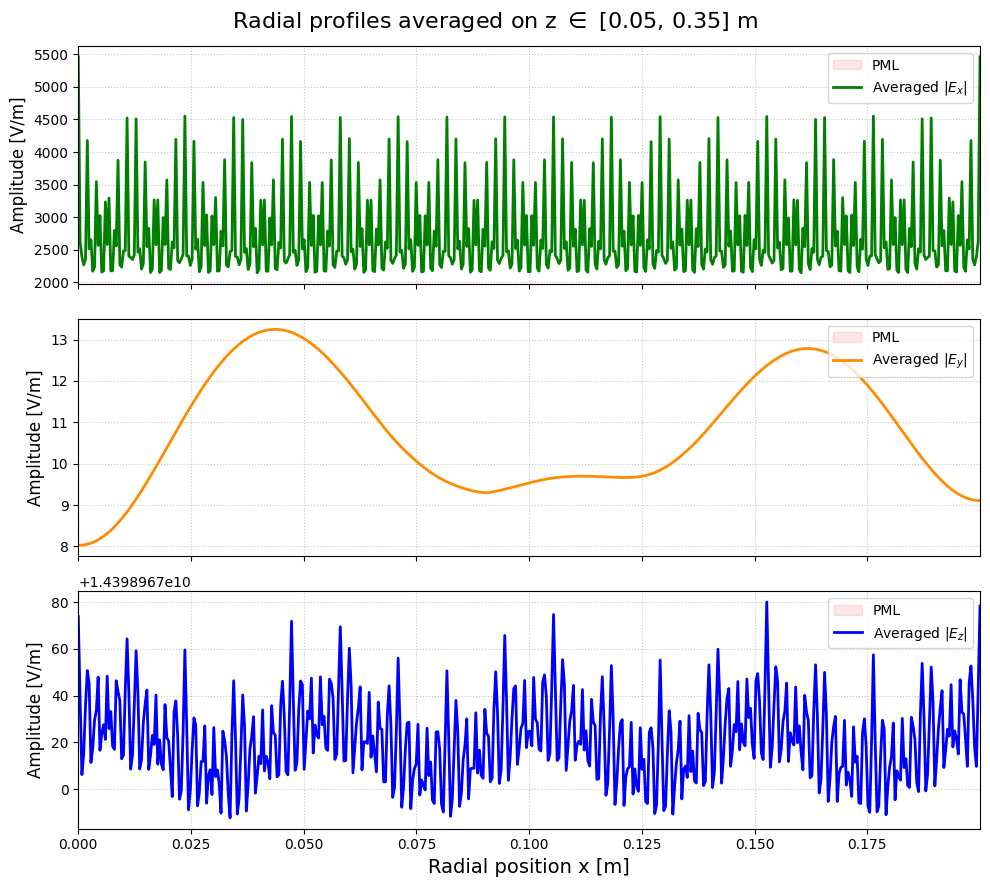

In [34]:
z_mid = cfg.DOMAIN['Lz_tot'] / 2.0
# my_pp.plot_radial_components(solver, z_target=z_mid)
my_pp.Plot_Radial_Components_Averaged(solver, sim_target_folder)

In [ ]:
my_pp.Plot_Density_Profile_2D(solver, sim_target_folder, resolution_x, resolution_z)

my_pp.Plot_B_Field_2D(solver, sim_target_folder)


--- [PLOT] 2D & 1D map generation of Density n_e ---


KeyError: 'Lx_plasma'